In [20]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score

In [ ]:
df = pd.read_csv("Customer-Churn-Records.csv")
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,1,5,DIAMOND,484
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0,0,2,SILVER,206
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,1,2,DIAMOND,282
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,0,3,GOLD,251
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,0,3,GOLD,342


In [3]:
df.drop(columns=["RowNumber", "CustomerId", "Surname", 'Complain'], inplace=True)
# First three features are useless, the last one is highly correlated with the target variable (Exited).
# This can be observed from the SHAP visualization, where its importance exceeds 80%.
# For code clarity and to avoid redundancy, the detailed verification process is omitted here.
# Instead, here we try to focus on secondary features, so we removed the "Complain" variable.

cat_cols = ["Geography", "Gender", "Card Type"]
for c in cat_cols:
    df[c] = df[c].astype("category")


In [4]:
X = df.drop("Exited", axis = 1)  # target feature 
y = df["Exited"]
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,5,GOLD,425


In [5]:
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size = 0.8, random_state = 42, stratify = y)

In [6]:
base = LGBMClassifier(
    n_estimators = 2000,
    objective = "binary",
    random_state = 42,
    n_jobs = -1
)

param_grid = {
    "n_estimators" : randint(400, 1200),
    "max_depth": randint(-1, 16),
    "num_leaves": randint(16, 256)
}

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator = base,
    param_distributions = param_grid,
    n_iter = 30,
    scoring = "roc_auc",
    cv = cv,
    random_state = 42,
    n_jobs = -1
)

In [8]:
search.fit(X_train, y_train)
best_model = search.best_estimator_
print("Best AUC:", search.best_score_)
print("Best params:", search.best_params_)

Best AUC: 0.8570176536872418
Best params: {'max_depth': 2, 'n_estimators': 401, 'num_leaves': 149}


In [ ]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18,25,35,45,55,65,100],
    labels=["18-25","25-35","35-45","45-55","55-65","65+"]
)

df["BalanceGroup"] = pd.cut(
    df["Balance"],
    bins=[-1, 0, 50000, 150000, df["Balance"].max()],
    labels=["Zero","Low","Mid","High"]
)

In [42]:
# 单指标分析 single metric Analysis 
features = [
    "AgeGroup",
    "Gender",
    "Geography",
    "NumOfProducts",
    "IsActiveMember",
    "BalanceGroup"
]

for f in features:
    print("\n",f)
    print(df.groupby(f)["Exited"].mean())


 AgeGroup
AgeGroup
18-25    0.074703
25-35    0.084980
35-45    0.196467
45-55    0.505721
55-65    0.483209
65+      0.132576
Name: Exited, dtype: float64

 Gender
Gender
Female    0.250715
Male      0.164743
Name: Exited, dtype: float64

 Geography
Geography
France     0.161747
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

 NumOfProducts
NumOfProducts
1    0.277144
2    0.076035
3    0.827068
4    1.000000
Name: Exited, dtype: float64

 IsActiveMember
IsActiveMember
0    0.268715
1    0.142691
Name: Exited, dtype: float64

 BalanceGroup
BalanceGroup
Zero    0.138236
Low     0.346667
Mid     0.241244
High    0.231166
Name: Exited, dtype: float64


  print(df.groupby(f)["Exited"].mean())


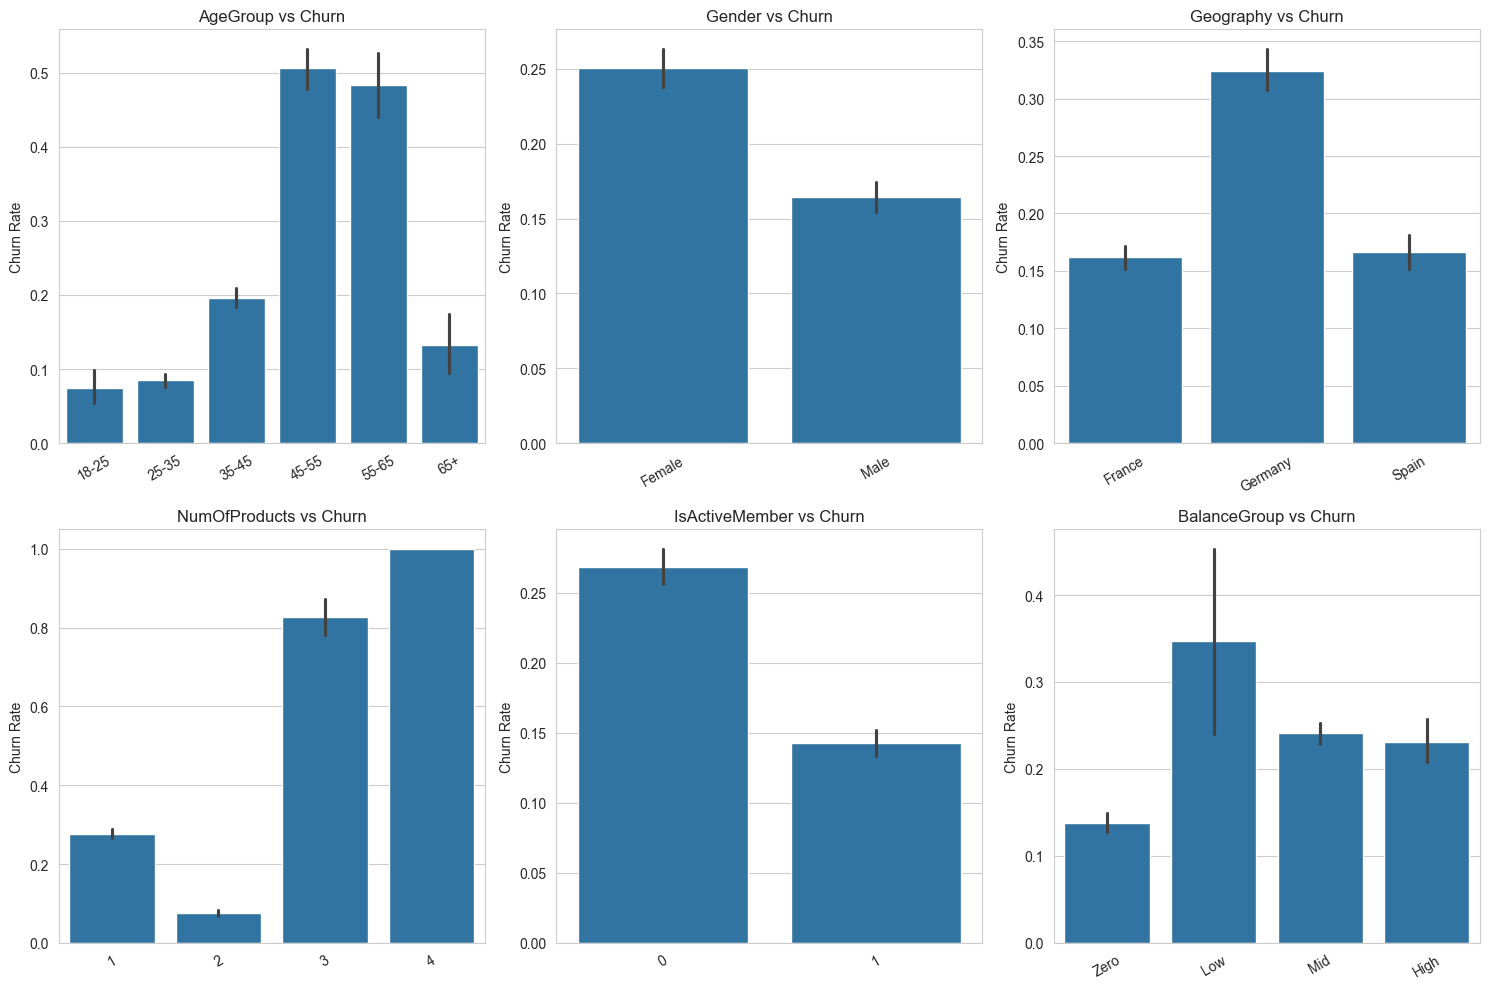

In [43]:
fig, axes = plt.subplots(2,3, figsize=(15,10))

axes = axes.flatten()

for i, col in enumerate(features):

    sns.barplot(
        x=col,
        y="Exited",
        data=df,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Churn Rate")

    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

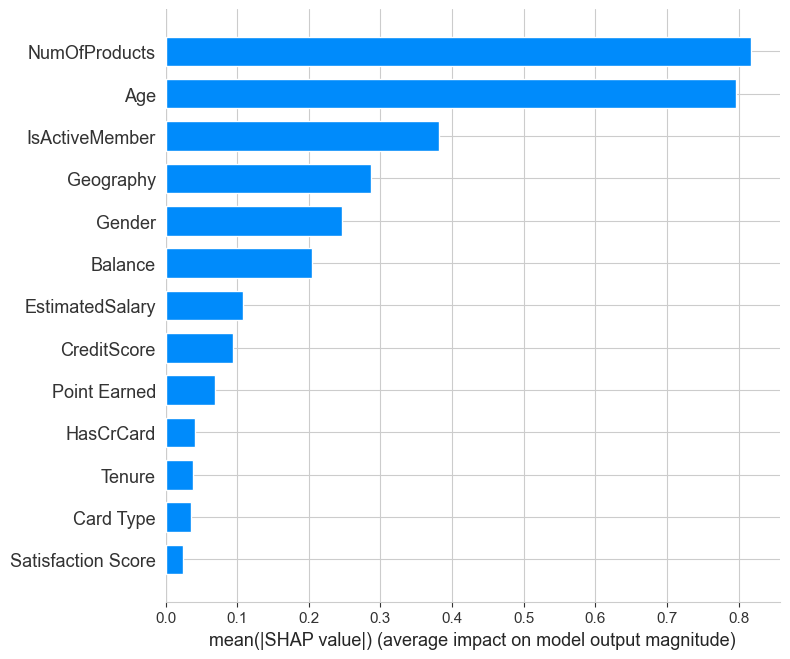

In [ ]:
explainer = shap.TreeExplainer(best_model)
X_sample = X_val.sample(1000, random_state=42) if len(X_val) > 1000 else X_val

sv = explainer(X_sample)

vals = sv.values
if vals.ndim == 3:
    vals = vals[:, :, 1]  # exited = 1

shap.summary_plot(vals, X_sample, plot_type="bar", max_display=20)

In [44]:
# 用户分层 User Segmentation
# Method 1: 根据 客户存款 + 活跃度 + 风险 分层 Segment customers based on customer balance, engagement and risk
df["churn_prob"] = best_model.predict_proba(X)[:,1]
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned,Cluster,AgeGroup,BalanceGroup,churn_prob
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464,1,35-45,Zero,0.305826
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456,0,35-45,Mid,0.230173
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377,2,35-45,High,0.945348
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350,2,35-45,Zero,0.046526
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425,0,35-45,Mid,0.097311


In [ ]:
def segment_user(row):

    if row["Balance"] > df["Balance"].quantile(0.75) and row["churn_prob"] < 0.3:  # high balance, low risk of exiting -> VIP benefits
        return "VIP_Stable"

    elif row["Balance"] > df["Balance"].quantile(0.75) and row["churn_prob"] > 0.7:  # high balance, high risk of exiting -> managers follow-up
        return "VIP_Risk"

    elif row["churn_prob"] > 0.7:  # low or medium balance, high risk of exiting -> promotion activity
        return "Churn_Risk"

    elif row["IsActiveMember"] == 0:  # low activity -> promotion activity
        return "Inactive"

    else:
        return "Normal"  # normal customers -> product recommendation

# 重点人群: Churn_Risk，VIP_Risk，Inactive (Priority groups: Churn_Risk，VIP_Risk，Inactive)
df["UserSegment"] = df.apply(segment_user, axis=1)

In [ ]:
df["UserSegment"].value_counts(normalize=True)
# 普通稳定客户占多数，其次是不活跃用户 The mojority are normal,loyal customers

UserSegment
Normal        0.3974
Inactive      0.3364
VIP_Stable    0.1881
Churn_Risk    0.0553
VIP_Risk      0.0228
Name: proportion, dtype: float64

In [57]:
segment_profile = df.groupby("UserSegment")[[
    "Age",
    "Balance",
    "NumOfProducts",
    "IsActiveMember",
    "Exited"
]].mean()

print(segment_profile)

                   Age        Balance  NumOfProducts  IsActiveMember    Exited
UserSegment                                                                   
Churn_Risk   50.701627   69665.674014       1.763110        0.153707  0.922242
Inactive     36.504162   56720.927916       1.549941        0.000000  0.178359
Normal       39.971817   55869.653110       1.534977        1.000000  0.128334
VIP_Risk     49.100877  149276.191316       1.881579        0.184211  0.925439
VIP_Stable   36.330144  148571.823796       1.373737        0.558214  0.110048


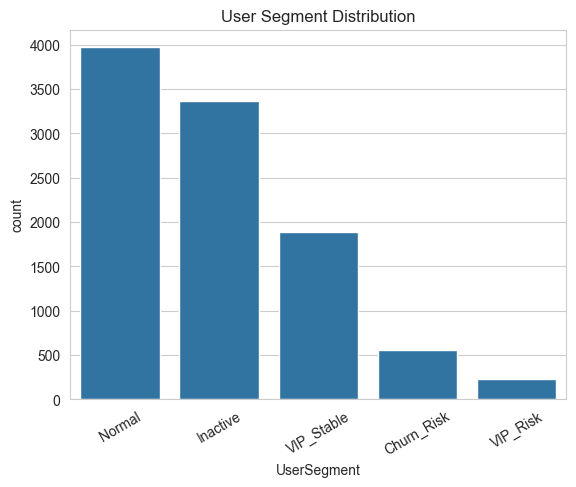

In [53]:
sns.countplot(
    x="UserSegment",
    data=df,
    order=df["UserSegment"].value_counts().index
)

plt.title("User Segment Distribution")
plt.xticks(rotation=30)
plt.show()

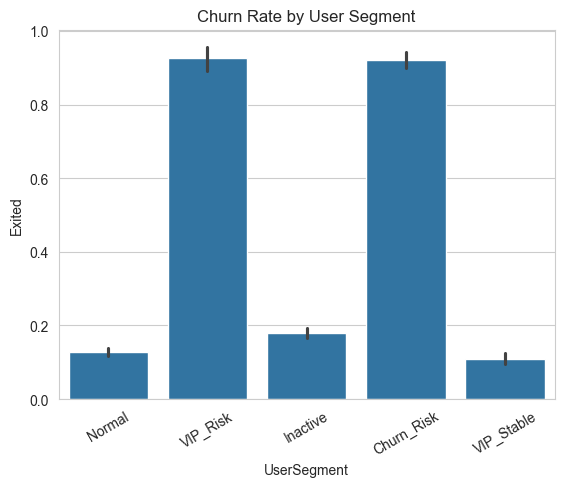

In [51]:
sns.barplot(
    x="UserSegment",
    y="Exited",
    data=df
)

plt.title("Churn Rate by User Segment")
plt.xticks(rotation=30)
plt.show()

In [58]:
# Method 2: 利用K-means分群 K-means clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [59]:
cluster_features = [
    "Age",
    "Balance",
    "NumOfProducts",
    "IsActiveMember",
    "EstimatedSalary",
    "Tenure"
]
X_cluster = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

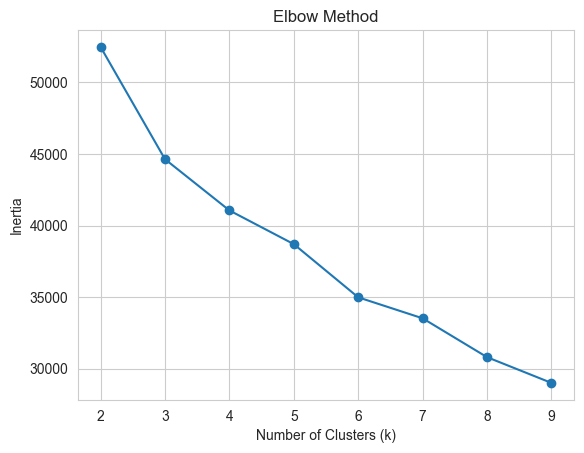

In [60]:
#  looking for a best k value using the elbow method
inertia_list = []
for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    inertia_list.append(kmeans.inertia_)

plt.figure()
plt.plot(range(2,10), inertia_list, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
#  The elbow appears at k = 3

In [61]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [64]:
df.groupby("Cluster")[[
    "Age",
    "NumOfProducts",
    "IsActiveMember",
    "Balance",
    "Exited"
]].mean()

#  the last cluster has the biggest probability of exiting

,Age,NumOfProducts,IsActiveMember,Balance,Exited
Cluster,,,,,
0,39.697030,1.293961,1.000000,122389.332279,0.154821
1,39.995036,1.908394,0.972022,11047.700749,0.143953
2,37.939628,1.503029,0.000000,78039.765862,0.262168


## 关键结论

综合指标分析、用户分层和聚类分析，得到以下核心结论：

### 1. 活跃度是影响流失的最关键因素
在用户分层结果中，`Inactive` 用户的活跃度为 `0`，流失率为 **17.84%**；`Churn_Risk` 用户的平均活跃度仅为 **0.154**，流失率高达 **92.22%**；`VIP_Risk` 用户的平均活跃度也只有 **0.184**，流失率达到 **92.54%**。  
同时在聚类结果中，**Cluster 2** 的 `IsActiveMember = 0`，其流失率为 **26.22%**，显著高于另外两个活跃用户群体（约 **14%~15%**）。  
这说明：**客户一旦不活跃，流失风险会明显上升。**

### 2. 产品绑定越强，客户越不容易流失
从分层结果看，`VIP_Stable` 用户平均持有产品数为 **1.37**，流失率仅为 **11.00%**；`Normal` 用户平均持有产品数为 **1.53**，流失率为 **12.83%**。  
而高风险群体中，`Churn_Risk` 用户平均产品数为 **1.76**，`VIP_Risk` 为 **1.88**。这说明单看产品数并不能完全决定是否流失，但在整体业务逻辑中，**产品绑定仍然是衡量客户黏性的重要指标**，需要结合活跃度和客户价值一起判断。  
尤其在前面的指标拆解中也可以看到，**持有产品数量较少的用户整体流失风险更高**。

### 3. 高价值客户需要重点维护
`VIP_Risk` 用户只有 **228 人**，但平均余额高达 **149,276**，是所有分层中资产规模最高的人群，且流失率达到 **92.54%**。  
相比之下，`VIP_Stable` 用户有 **1,881 人**，平均余额为 **148,572**，流失率仅为 **11.00%**。  
这说明：**高价值客户并不一定稳定，一旦高资产客户流失，对银行造成的损失会远高于普通客户，因此需要优先识别并重点维护 `VIP_Risk` 群体。**

### 4. 高风险用户主要集中在以下几类人群

- **不活跃用户**：如 `Inactive`、`Churn_Risk`、`VIP_Risk`，活跃度普遍较低
- **年龄较大的用户**：`Churn_Risk` 平均年龄 **50.70** 岁，`VIP_Risk` 平均年龄 **49.10** 岁，明显高于 `Normal`（**39.97** 岁）和 `VIP_Stable`（**36.33** 岁）
- **资产较高但活跃度不足的用户**：`VIP_Risk` 平均余额接近 **15 万**，但活跃度仅 **0.184**
- **聚类中的不活跃群体**：Cluster 2 用户平均活跃度为 **0**，流失率 **26.22%**，是聚类结果中风险最高的一组

### 5. 用户分层结果显示，当前最值得重点关注的两类用户是：

- **`VIP_Risk`**：人数少（**228人**），但余额最高（**149,276**），流失率最高（**92.54%**）
- **`Churn_Risk`**：人数 **533人**，流失率高达 **92.22%**，且平均年龄偏大、活跃度很低

这两类用户虽然总人数不多，但都属于**高风险核心人群**，其中 `VIP_Risk` 更是典型的 **高价值高流失用户**，应作为后续精细化运营的重点对象。